In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [58]:
titData = pd.read_csv('Titanic-Dataset.csv')

In [59]:
titData.shape

(891, 12)

In [60]:
titData.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [61]:
titData.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

#### Why age has float64 has dtype --> some values are floating point



In [62]:
titData.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [63]:
titData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### Above we can see inconsistencies in Age , Cabin , Embarked
##### Embarked missing values - 2
##### Age missing values - 177
##### Cabin missing values - 687


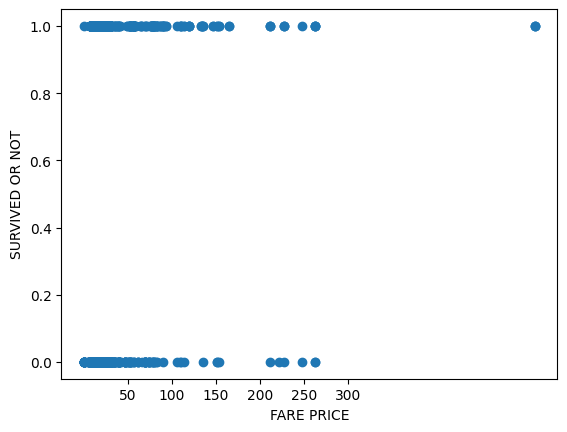

In [64]:
plt.scatter(titData['Fare'],titData['Survived'])
plt.xticks([50,100,150,200,250,300])
plt.xlabel("FARE PRICE")
plt.ylabel("SURVIVED OR NOT")
plt.show()

#### Above we can see an Outlier in fair price with Fare --> 512.3292


In [65]:
titData['Fare'].max()

np.float64(512.3292)

In [66]:
titData['Fare'].sort_values(ascending=False)

258    512.3292
737    512.3292
679    512.3292
88     263.0000
27     263.0000
         ...   
633      0.0000
413      0.0000
822      0.0000
732      0.0000
674      0.0000
Name: Fare, Length: 891, dtype: float64

### There are 3 outlier in Fares with Fare 512.3292


In [67]:
titData.loc[titData['Fare']==0].shape

(15, 12)

#### WE Can conclude 15 people travelled without any fare , which might an error in data collection 


----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
## TASK 2

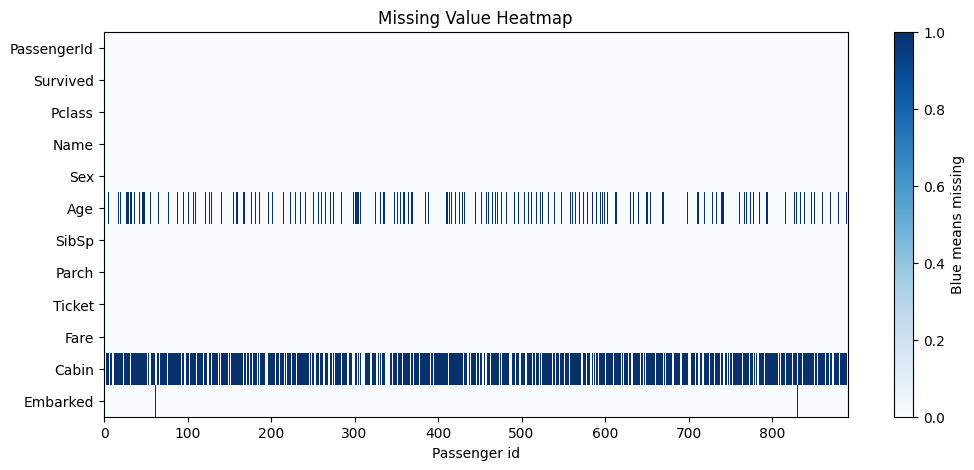

In [68]:
plt.figure(figsize=(12, 5))
plt.imshow(titData.isnull().T, aspect='auto', cmap='Blues', interpolation='nearest')

plt.colorbar(label='Blue means missing')

plt.yticks(range(len(titData.columns)), titData.columns)
plt.xlabel('Passenger id')

plt.title('Missing Value Heatmap')

plt.show()

## FIXES 

### CABIN --> since so many values are missing , we will be dropping this column

In [69]:
titData.drop(columns=['Cabin'], inplace=True)


### EMBARKED --> filling with the most common as only 2 values are missing

In [70]:
titData['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [71]:
titData['Embarked'].fillna('S',inplace = True)


/var/folders/36/40xg61dj0qz6lkh7nxvrpv4r0000gn/T/ipykernel_23433/343317011.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titData['Embarked'].fillna('S',inplace = True)


### AGE --> filling with mean values

#### since 177 values are missing , which is 20% of the data so it wouldn't be wise to just remove 20% of the data , instead filling them with mean values 

In [72]:
titData['Age'].fillna(titData['Age'].mean(),inplace=True)

/var/folders/36/40xg61dj0qz6lkh7nxvrpv4r0000gn/T/ipykernel_23433/1743594545.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titData['Age'].fillna(titData['Age'].mean(),inplace=True)


### AGE --> converting to int , age must be an integer 

In [73]:
titData['Age'] = titData['Age'].astype(int)

### FARE --> filling the 0 fare with mean , which me might error in data collection

In [74]:
titData.loc[titData['Fare'] ==0,'Fare'] = titData['Fare'].mean()

----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
## TASK 3

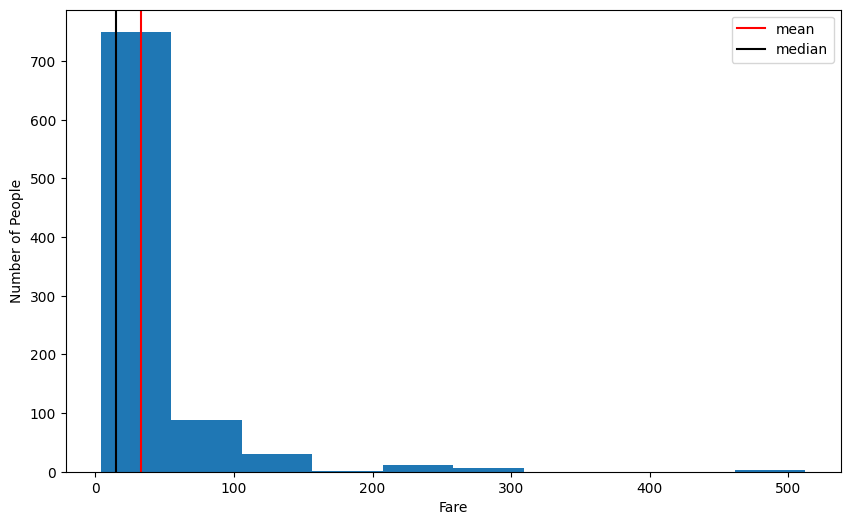

In [75]:
plt.figure(figsize=(10,6),dpi=100)

plt.hist(titData['Fare'])
plt.xlabel('Fare')
plt.ylabel('Number of People')
plt.axvline(x = titData['Fare'].mean(),color = 'red',label='mean')
plt.axvline(x= titData['Fare'].median(),color = 'black',label = 'median')
plt.legend()
plt.show()




### The Plot is Right Skewed --> there is a tail to the right and median < mean
### This tells us that many people paid less while a small group of people paid a lot

-----------------------------------------------------------------------------------------------------------------------------------------------------------------
## TASK 4


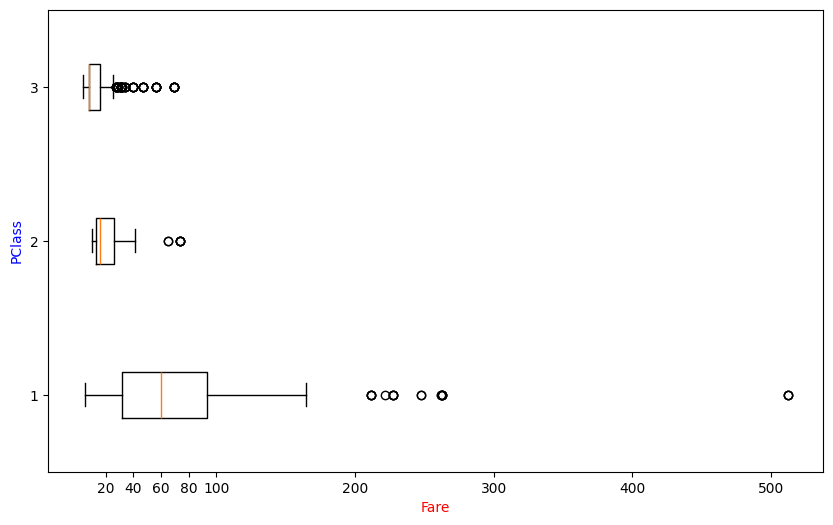

<Figure size 640x480 with 0 Axes>

In [76]:
p1 = np.array(titData.loc[titData['Pclass']==1,'Fare'])
p2 = np.array(titData.loc[titData['Pclass']==2,'Fare'])
p3 = np.array(titData.loc[titData['Pclass']==3,'Fare'])

plt.figure(figsize=(10,6),dpi=100)
# p = np.hstack((p1,p2,p3))
plt.boxplot((p1,p2,p3),vert=False)
plt.xlabel('Fare',color = "red")
plt.ylabel('PClass',color = 'Blue')
plt.xticks([20,40,60,80,100,200,300,400,500])


plt.show()
plt.tight_layout()



### Pclass 1
#### Multiple dots spread from 200 to 300
#### extreme outlier near 500 --> those who got large cabins , private suites

### Pclass 2
#### Small group of people overpaid fare of 60 to 80
#
### Pclass 3
#### Several dots clustered around 20-40 fare range -->these people overpaid compared to other 3rd class

-----------------------------------------------------------------------------------------------------------------------------------------------------------------

## TASK 5

In [77]:
titData.groupby('Survived')['Age'].count()

Survived
0    549
1    342
Name: Age, dtype: int64

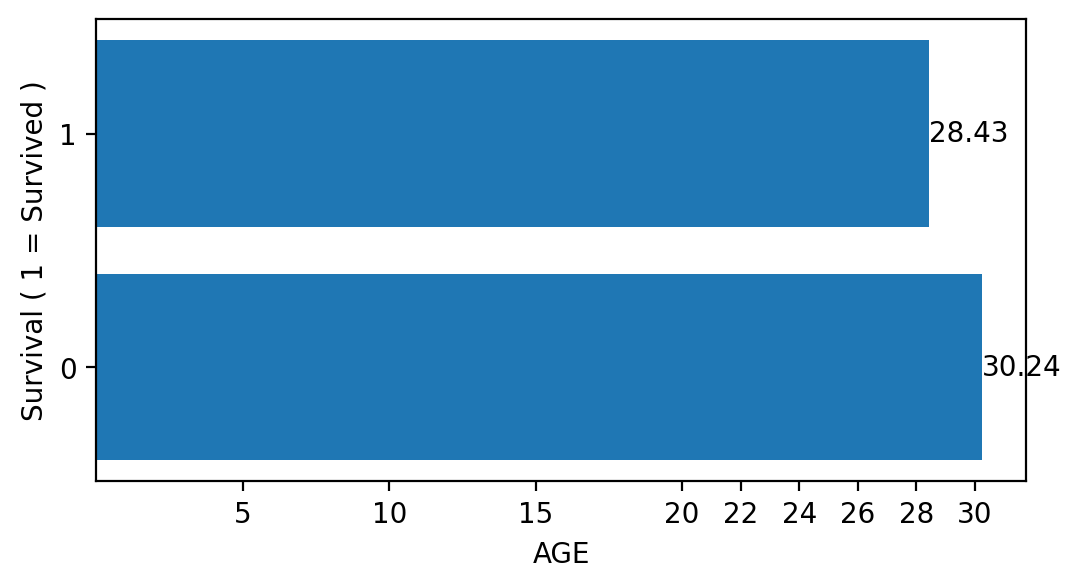

In [78]:
plt.figure(figsize=(6,3),dpi=200)

bars = plt.barh(y = [1,0],width=list(map(lambda x : round(x,2),titData.groupby('Survived')['Age'].mean().sort_values())))
plt.xticks((5,10,15,20,22,24,26,28,30))
plt.yticks((0,1))
plt.ylabel('Survival ( 1 = Survived )')
plt.xlabel('AGE')

plt.bar_label(bars)

plt.show()

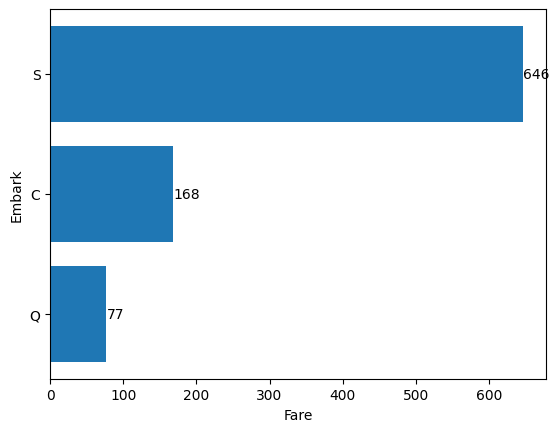

In [79]:
bars = plt.barh(y =['Q','C','S'],width=list(titData.groupby('Embarked')['Fare'].count().sort_values()),)
plt.bar_label(bars)
plt.ylabel('Embark')
plt.xlabel('Fare')
plt.show()

-----------------------------------------------------------------------------------------------------------------------------------------------------------------
## TASK 6

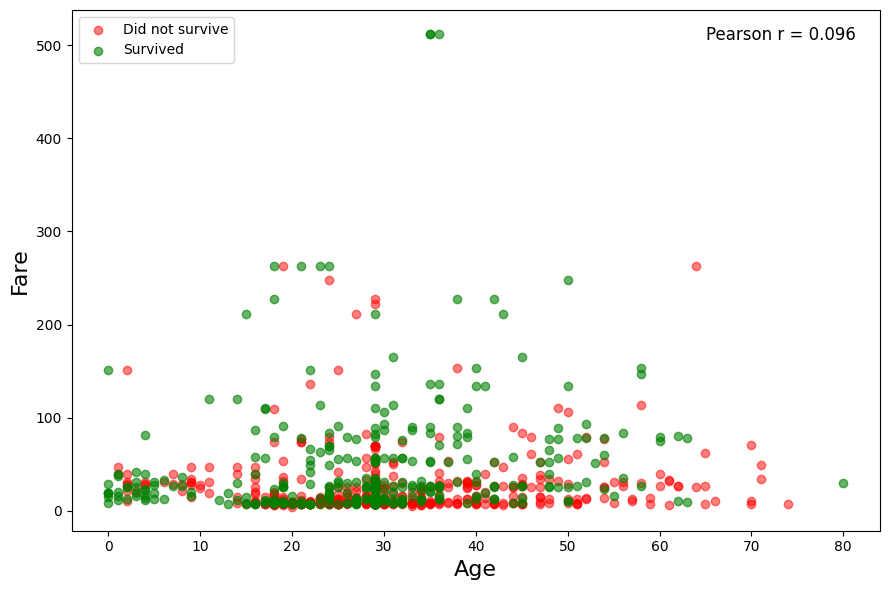

In [80]:
r = np.corrcoef(titData['Age'], titData['Fare'])[0, 1]

survived = titData[titData['Survived'] == 1]
died     = titData[titData['Survived'] == 0]
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(died['Age'],     died['Fare'],     color='red',   alpha=0.5,  label='Did not survive')

ax.scatter(survived['Age'], survived['Fare'], color='green', alpha=0.6,  label='Survived')
ax.set_xlabel('Age',fontdict={'fontsize':16})

ax.set_ylabel('Fare',fontdict={'fontsize':16})

ax.legend()


ax.text(0.97, 0.97, f'Pearson r = {round(r,3)}',
        transform=ax.transAxes, ha='right', va='top', fontsize=12,)


plt.tight_layout()


plt.show()

### Pearson r = 0.096 — Weak, and misleading
#### Weak r ≈ 0.10 means Age and Fare share almost no linear
#### relationship ,  Knowing someone's age tells you almost nothing
#### about what they paid.

-----------------------------------------------------------------------------------------------------------------------------------------------------------------
## TASK 7


In [81]:
titData.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')

#### Plotting without PassengerId , this is not an identifier
#### converting male and female to 1 and 0


In [82]:
titData.loc[titData['Sex'] == 'male','Sex'] = 1
titData.loc[titData['Sex'] == 'female','Sex'] = 0
titData['Sex'] = titData['Sex'].astype(int)


### converting embared to integers using one-hot encoding

In [83]:
# Creates separate 0/1 column for each category
titData = pd.get_dummies(titData, columns=['Embarked'])

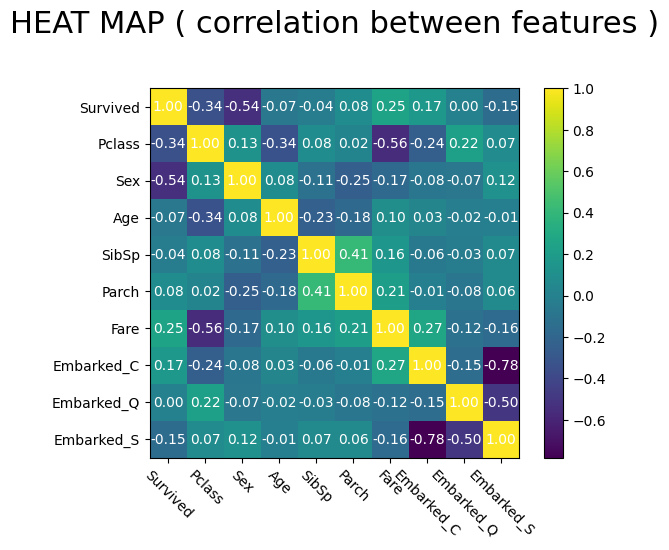

In [84]:
titDataNew = titData.drop('PassengerId',axis=1)
plt.imshow(titDataNew.corr(numeric_only=True))

corr = titDataNew.corr(numeric_only=True)

plt.xticks(range(len(corr)), corr.columns, rotation=-45)


plt.yticks(range(len(corr)), corr.columns)

for i in range(len(corr)):
    for j in range(len(corr)):
        plt.text(j, i, f"{corr.iloc[i,j]:.2f}",ha = 'center', va='center', color='white')

plt.title("HEAT MAP ( correlation between features )",pad=40,fontdict={'fontsize':22},loc='center')

plt.colorbar()
plt.show()

### PCLASS and FARE are decently negavtively correlated
### PARCH and PCLASS are nearly completely unrelated

---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## TASK 8

#### There is not a time column , so we will using AGE column

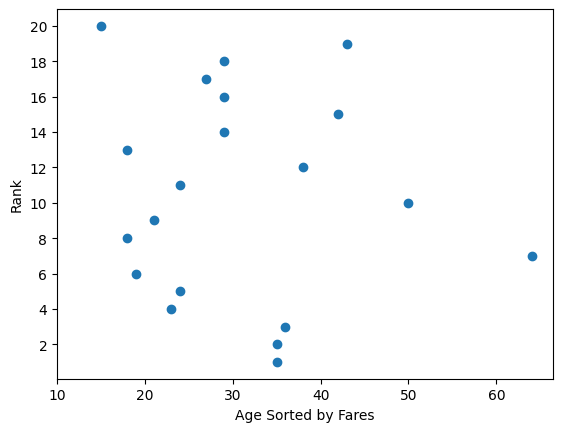

In [85]:
topAges = np.array(titData.sort_values(by='Fare',ascending=False)['Age'][:20])
rank = np.arange(1,21)
plt.scatter(topAges,rank)
plt.xticks([10,20,30,40,50,60])
plt.yticks(np.arange(2,21,2))
plt.xlabel('Age Sorted by Fares')
plt.ylabel('Rank')
plt.show()

----------------------------------------------------------------------------------------------------------------------------------------------------------------
## TASK 9

In [86]:
counts = titData['Pclass'].value_counts()
counts 

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

Text(0.5, 1.0, 'Passenger Class Split')

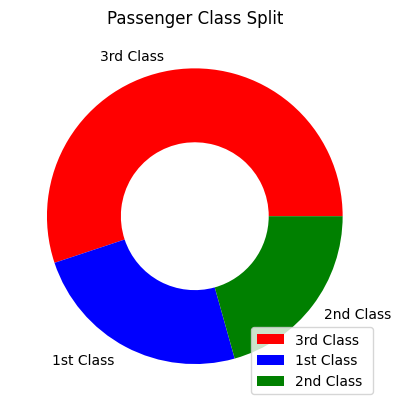

In [87]:
plt.pie(counts,
        labels=['3rd Class ','1st Class ','2nd Class '],
        colors=['red','blue','green'],
        wedgeprops={'width': 0.5},
)

plt.legend()
plt.title('Passenger Class Split')


 Bar Chart is much better for comparison between values as we can easily see their  lengths , therefore easily doing comparison<br>
 Pie Chart is used to show a category as relative proportion of the whole class , while bar chart gives absolute value<br>
 Pie Chart can only display 1 varaible while bar chart can show 2 variables <br>
 If there are many categories to a class , it becomes really confusing and messy on the pie chart <br>

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------
## TASK 10

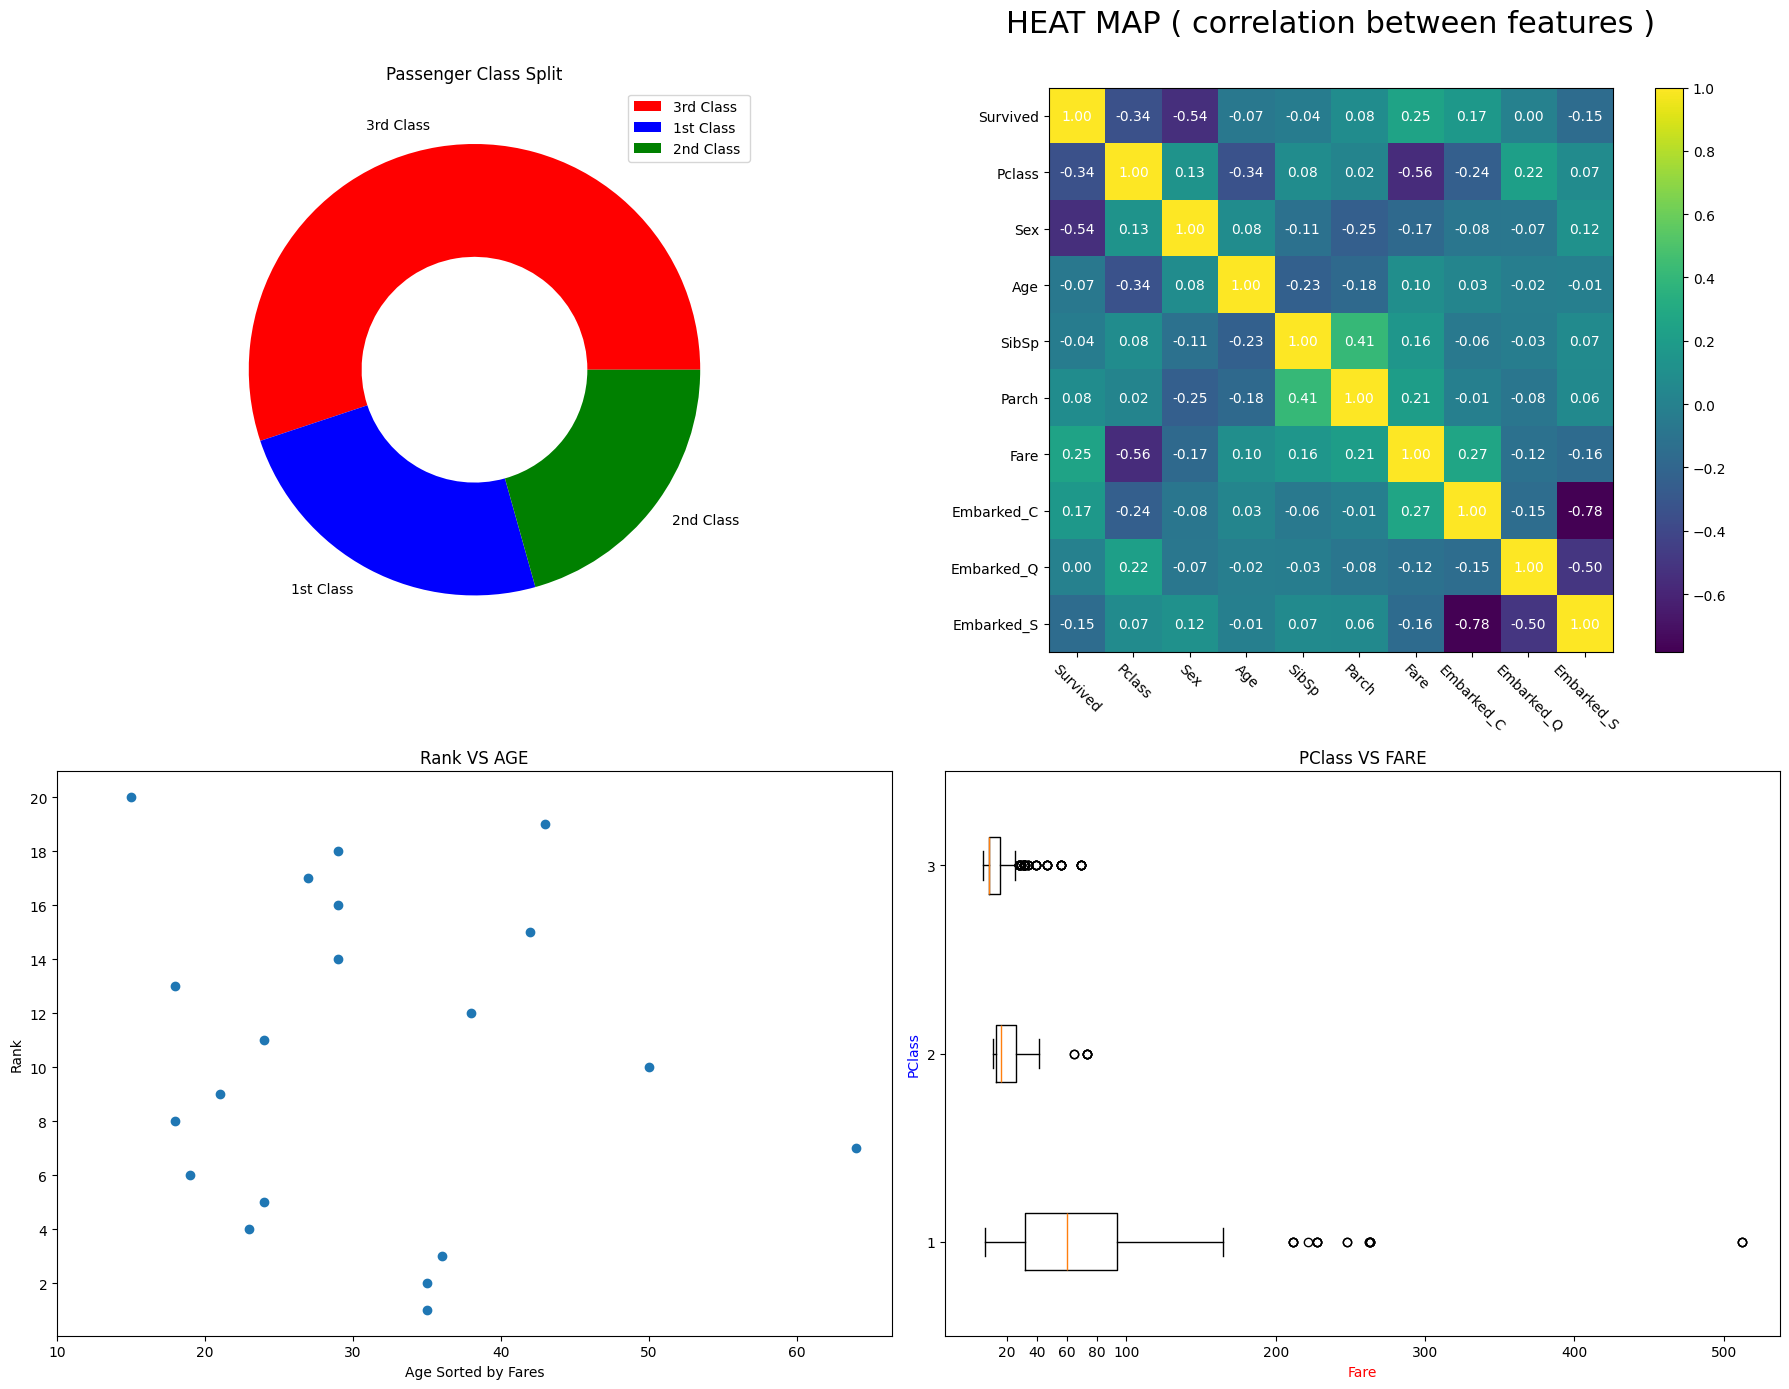

In [88]:
fig = plt.figure(figsize=(18, 14))

plt.subplot(2, 2, 1)
plt.pie(counts,
        labels=['3rd Class ','1st Class ','2nd Class '],
        colors=['red','blue','green'],
        wedgeprops={'width': 0.5},
)

plt.legend()
plt.title('Passenger Class Split')



plt.subplot(2, 2, 2)
titDataNew = titData.drop('PassengerId',axis=1)
plt.imshow(titDataNew.corr(numeric_only=True))

corr = titDataNew.corr(numeric_only=True)

plt.xticks(range(len(corr)), corr.columns, rotation=-45)


plt.yticks(range(len(corr)), corr.columns)

for i in range(len(corr)):
    for j in range(len(corr)):
        plt.text(j, i, f"{corr.iloc[i,j]:.2f}",ha = 'center', va='center', color='white')

plt.title("HEAT MAP ( correlation between features )",pad=40,fontdict={'fontsize':22},loc='center')
plt.colorbar()



plt.subplot(2, 2, 3)

plt.scatter(topAges,rank)
plt.xticks([10,20,30,40,50,60])
plt.yticks(np.arange(2,21,2))
plt.xlabel('Age Sorted by Fares')
plt.ylabel('Rank')
plt.title('Rank VS AGE')

plt.subplot(2,2,4)
p1 = np.array(titData.loc[titData['Pclass']==1,'Fare'])
p2 = np.array(titData.loc[titData['Pclass']==2,'Fare'])
p3 = np.array(titData.loc[titData['Pclass']==3,'Fare'])

# p = np.hstack((p1,p2,p3))
plt.boxplot((p1,p2,p3),vert=False)
plt.xlabel('Fare',color = "red")
plt.ylabel('PClass',color = 'Blue')
plt.xticks([20,40,60,80,100,200,300,400,500])
plt.title('PClass VS FARE')


plt.tight_layout()

plt.show()

fig.savefig('summary.png', dpi=150, bbox_inches='tight')





## TASK 11


In [89]:
titData['Fare'].describe()

Q1 = 7.925
Q3 = 32.204


IQR = (Q3 - Q1) 

lower = Q1 - (1.5)*(IQR)
upper = Q3 + (1.5)*(IQR)

outlier = titData.loc[(titData['Fare'] > upper) | (titData['Fare'] < lower) ]
outlier.shape 

count = outlier.shape[0]
percentage = ((count)/(titData['Fare'].shape[0])*100)

regular = titData.loc[(titData['Fare'] <= upper) & (titData['Fare'] >= lower) ]



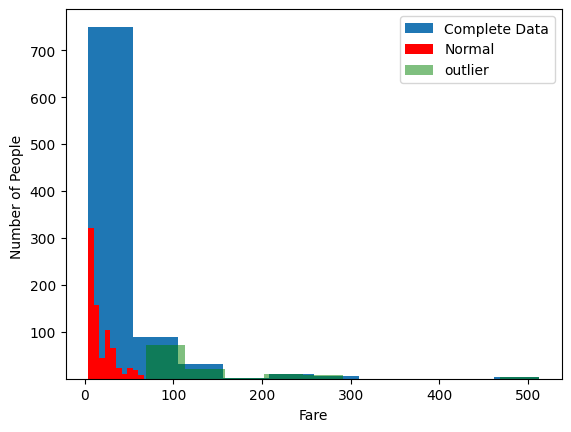

In [90]:
plt.hist(titData['Fare'],label = 'Complete Data')
plt.hist(regular['Fare'],color='red',label = 'Normal')
plt.hist(outlier['Fare'],color='green',alpha = 0.5,label='outlier')
plt.yticks([100,200,300,400,500,600,700])
plt.xlabel('Fare')
plt.ylabel('Number of People ')
plt.legend()
plt.show()

No, i will not remove them

These are not data errors. The high fares are real
first class cabin prices. Removing them would delete real
signal: fare is strongly linked to Pclass, which is one of
the strongest predictors of survival.

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
## TASK 12

### LINEAR REGRESSION FROM SCRATCH


In [91]:
pClass_feature = np.array(titData['Pclass'])
fare_label     = np.array(titData['Fare'])
 
dataset = np.vstack((pClass_feature, fare_label))
dataset = dataset.T

np.random.seed(9)
np.random.shuffle(dataset)
 
X = dataset[:, 0]
y = dataset[:, 1]
 
X_train = X[:int(len(X)*4/5)]
X_test  = X[int(len(X)*4/5):]
y_train = y[:int(len(y)*4/5)]
y_test  = y[int(len(y)*4/5):]
 
X_train = (X_train - np.mean(X_train)) / (np.std(X_train))
y_train = (y_train - np.mean(y_train)) / (np.std(y_train))
 
X_train = X_train.reshape(-1, 1)
y_train = y_train.reshape(-1, 1)
 
X_train_b = np.hstack((X_train, np.ones(X_train.shape)))
 
beta  = np.linalg.inv(X_train_b.T @ X_train_b) @ (X_train_b.T @ y_train)
W,B = beta[0], beta[1]
 
print("beta:", beta)
print("B:", B, "W:", W)
 

beta: [[-5.57186952e-01]
 [ 4.08373088e-17]]
B: [4.08373088e-17] W: [-0.55718695]


In [92]:
X_test = (X_test - np.mean(X_test)) / (np.std(X_test))
y_test = (y_test - np.mean(y_test)) / (np.std(y_test))

X_test = X_test.reshape(-1,1)

In [93]:
pred = X_test@W + B

 
 ### 1
 we have 1 feature pclass and label as fare<br>

 we have to make the X dataset such that each row as one element  of pclass and fare<br>

 np.vstack <br>

then transpose <br>

 shuffly the dataset for non-biased training <br>

 then take first 80% as train and next 20% as test<br>

 (each value - mean)/std  --> standardizing the data -->  apply only on X_train and y_train<br>

 X_train.reshape(-1,1) --> automatically reshapes the vector to a matrix for matrix operations<br>

 horizontal stack np.ones(len(X)) to X_train <br>

 beta = (np.linalg.inv(X.T@X))@(X.T)@(y) --> getting the final values of the optimal parameters<br>

 W = beta[1:] --> getting thet slope<br>

 B = beta[0] --> y - intercept<br>

 pred = X@W + B --> doing prediction <br>

 MSE = 1/n(np.sum((y - pred)**2)) --> finding error in our predictions<br>

 SS(fit ) = MSE*n --> finding the sum of squares around the fitted line<br>

 SS(mean) = np.sum((y-np.mean(y))**2) --> finding the sum of squares around the mean<br>

 Rsquare = 1 -(SS(fit))/(SS(mean)) --> finding how good our model is <br>

 plt.scatter(x = X_test[:,0],y=pred) --> plotting the our predicted values<br>

 plt.scatter(x = X_test[:0],y=y_test) --> plotting the actual values<br>

### 2
Normalization scales every feature to the same range , so they can be plotted on the graph and also so the model doesn't give preference to bigger numbers 

### 3

The equation for fitted line would is ;<br>
    y = beta[0] + beta[1]*X <br>

if we do not add array of ones to X , we wouldn't be abl to calculate the beta[0] and so our line would have no intercept 


In [94]:
n = len(X_test)
MSE = (1/n)*(np.sum((y_test-pred)**2))
SS_fit = MSE*n
SS_mean = np.sum((y_test-np.mean(y_test))**2)
Rsquare = 1 -(SS_fit)/(SS_mean)
Rsquare,MSE

(np.float64(0.43172006906142624), np.float64(0.5682799309385738))

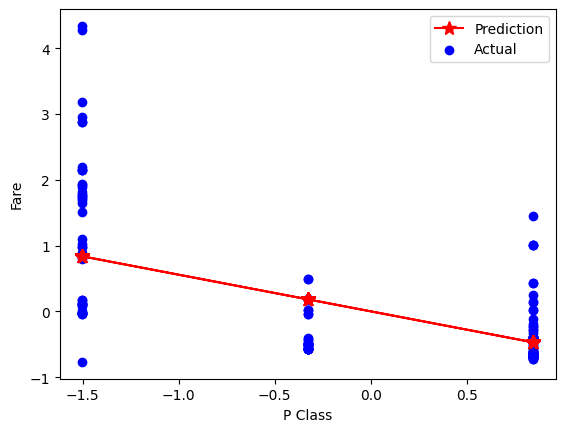

In [95]:
plt.plot( X_test,pred,color = 'red',marker = "*",markersize = 10,label = 'Prediction')
plt.scatter(x = X_test,y=y_test,color = 'blue',label = 'Actual')
plt.xlabel('P Class')
plt.ylabel('Fare')
# plt.xticks[]
plt.legend()

plt.show()


-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
## TASK 13

In [96]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [97]:
scaler = StandardScaler(copy=False)

In [98]:
pClass_feature = np.array(titData['Pclass'])
fare_label     = np.array(titData['Fare'])

dataset = np.vstack((pClass_feature, fare_label))
dataset = dataset.T

np.random.seed(9)
np.random.shuffle(dataset)
 
X = dataset[:, 0]
y = dataset[:, 1]

X = X.reshape(-1,1)
y = y.reshape(-1,1)

SL_X_train = X[:int(len(X)*4/5)]
SL_X_test  = X[int(len(X)*4/5):]
SL_y_train = y[:int(len(y)*4/5)]
SL_y_test  = y[int(len(y)*4/5):]



In [99]:
SL_X_train = scaler.fit_transform(SL_X_train)
SL_y_train = scaler.fit_transform(SL_y_train)
SL_X_test = scaler.fit_transform(SL_X_test)
SL_y_test = scaler.fit_transform(SL_y_test)


In [100]:
model = LinearRegression()

In [101]:
model.fit(SL_X_train,SL_y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [102]:
SL_pred = model.predict(SL_X_test)

In [103]:
SL_MSE = mean_squared_error(SL_y_test,SL_pred)
SL_Rsquare = r2_score(SL_y_test,SL_pred)

In [104]:
SL_MSE

0.568279930938574

In [105]:
SL_Rsquare

0.431720069061426

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
## TASK 14

1) Yes , the values from scikit learn match perfectly with the from-scratch linear model <br>
    SL_MSE = MSE = 0.57 <br>
    SL_Rsquare = Rsquare = 0.431 <br>
    SL_pred = pred <br>

    this means that i have correctly implement the standardization and parameters calculation<br>
    <br>
2) We got :<br>
    W = -0.55718695 <br>
    B = 4.08373088e-17 <br>
    We can see that B > W , and B is positive so it has the largest positive effect on the target varibale , though not very much ,<br>
    while W has least positive effect infact negative effect<br>
    <br>

3) R² just gives us  summary "the model explains 43% of variance." That sounds uniform. <br>
    But the scatter plot shows something R² hides<br>

    At 1st class (left side, P Class ≈ -1.5), the actual fares (blue dots) shoot up to 4–5x the predicted value. The model severely underpredicts high-paying passengers.<br>
    At 3rd class (right side, P Class ≈ 0.75), the actual values cluster tightly near zero — the model does relatively okay there.

4)  My Rsquare = 0.431 , it is very low and close to 0.4 <br>
    This is happening due to low correlation between pclass and fare <br>
    Our feature pclass doesn't take continuous values , only takes 1,2,3 and all the output values are centered on these , so it is difficult to model such distribution as a linear relationship<br>

    YES , Adding Extra features should help as they bring in more complexity to the model and will make the predictions better and improve R_square

